# 📊 Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the cleaned Olist E-commerce dataset to uncover business insights through statistical analysis and visualizations.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

## 📂 Step 1: Load Cleaned Datasets

In [3]:
customers = pd.read_csv("../data/cleaned/customers_cleaned.csv")
orders = pd.read_csv("../data/cleaned/orders_cleaned.csv")
order_items = pd.read_csv("../data/cleaned/order_items_cleaned.csv")
payments = pd.read_csv("../data/cleaned/payments_cleaned.csv")
reviews = pd.read_csv("../data/cleaned/reviews_cleaned.csv")
products = pd.read_csv("../data/cleaned/products_cleaned.csv")
sellers = pd.read_csv("../data/cleaned/sellers_cleaned.csv")
geolocation = pd.read_csv("../data/cleaned/geolocation_cleaned.csv")
category = pd.read_csv("../data/cleaned/category_translation_cleaned.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


## 🔗 Step 2: Merge the Datasets

In [4]:
merged = pd.merge(
    customers,
    orders,
    on="customer_id",
    how="inner"
)

print(merged.shape)
merged.head()

(99441, 12)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15


In [5]:
merged = pd.merge(
    merged,
    order_items,
    on="order_id",
    how="inner"
)

print(merged.shape)
merged.head()

(112650, 18)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,1,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,1,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,1,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,1,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25


In [7]:
merged = pd.merge(
    merged,
    products,
    on="product_id",
    how="left"
)

print(merged.shape)
merged.head()

(112650, 34)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_height_cm_x,product_width_cm_x,product_category_name_y,product_name_lenght_y,product_description_lenght_y,product_photos_qty_y,product_weight_g_y,product_length_cm_y,product_height_cm_y,product_width_cm_y
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,64.0,31.0,moveis_escritorio,41.0,1141.0,1.0,8683.0,54.0,64.0,31.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,15.0,40.0,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,52.0,17.0,moveis_escritorio,55.0,955.0,1.0,8267.0,52.0,52.0,17.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,51.0,28.0,moveis_escritorio,48.0,1066.0,1.0,12160.0,56.0,51.0,28.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,15.0,35.0,casa_conforto,61.0,407.0,1.0,5200.0,45.0,15.0,35.0


In [14]:
print(merged.columns.tolist())

['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name_x', 'product_name_lenght_x', 'product_description_lenght_x', 'product_photos_qty_x', 'product_weight_g_x', 'product_length_cm_x', 'product_height_cm_x', 'product_width_cm_x', 'product_category_name_y', 'product_name_lenght_y', 'product_description_lenght_y', 'product_photos_qty_y', 'product_weight_g_y', 'product_length_cm_y', 'product_height_cm_y', 'product_width_cm_y']


In [15]:
print(category.columns.tolist())

['product_category_name', 'product_category_name_english']


In [16]:
merged[["product_category_name_x", "product_category_name_y"]].head()

,product_category_name_x,product_category_name_y
0,moveis_escritorio,moveis_escritorio
1,utilidades_domesticas,utilidades_domesticas
2,moveis_escritorio,moveis_escritorio
3,moveis_escritorio,moveis_escritorio
4,casa_conforto,casa_conforto


In [17]:
merged = pd.merge(
    merged,
    category,
    left_on="product_category_name_y",
    right_on="product_category_name",
    how="left"
)

print(merged.shape)
merged.head()

(112650, 36)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_category_name_y,product_name_lenght_y,product_description_lenght_y,product_photos_qty_y,product_weight_g_y,product_length_cm_y,product_height_cm_y,product_width_cm_y,product_category_name,product_category_name_english
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,moveis_escritorio,41.0,1141.0,1.0,8683.0,54.0,64.0,31.0,moveis_escritorio,office_furniture
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0,utilidades_domesticas,housewares
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,moveis_escritorio,55.0,955.0,1.0,8267.0,52.0,52.0,17.0,moveis_escritorio,office_furniture
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,moveis_escritorio,48.0,1066.0,1.0,12160.0,56.0,51.0,28.0,moveis_escritorio,office_furniture
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,casa_conforto,61.0,407.0,1.0,5200.0,45.0,15.0,35.0,casa_conforto,home_confort


In [18]:
merged = pd.merge(
    merged,
    payments,
    on="order_id",
    how="left"
)

print(merged.shape)
merged.head()

(117604, 40)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_weight_g_y,product_length_cm_y,product_height_cm_y,product_width_cm_y,product_category_name,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,8683.0,54.0,64.0,31.0,moveis_escritorio,office_furniture,1.0,credit_card,2.0,146.87
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,10150.0,89.0,15.0,40.0,utilidades_domesticas,housewares,1.0,credit_card,8.0,335.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,8267.0,52.0,52.0,17.0,moveis_escritorio,office_furniture,1.0,credit_card,7.0,157.73
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,12160.0,56.0,51.0,28.0,moveis_escritorio,office_furniture,1.0,credit_card,1.0,173.30
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,5200.0,45.0,15.0,35.0,casa_conforto,home_confort,1.0,credit_card,8.0,252.25


In [19]:
merged = pd.merge(
    merged,
    reviews,
    on="order_id",
    how="left"
)

print(merged.shape)
merged.head()

(118310, 46)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,1.0,credit_card,2.0,146.87,88b8b52d46df026a9d1ad2136a59b30b,4.0,NaN,NaN,2017-05-26 00:00:00,2017-05-30 22:34:40
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,1.0,credit_card,8.0,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,NaN,NaN,2018-01-30 00:00:00,2018-02-10 22:43:29
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,1.0,credit_card,7.0,157.73,5ad6695d76ee186dc473c42706984d87,5.0,NaN,NaN,2018-06-15 00:00:00,2018-06-15 12:10:59
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,1.0,credit_card,1.0,173.30,059a801bb31f6aab2266e672cab87bc5,5.0,NaN,NaN,2018-03-29 00:00:00,2018-04-02 18:36:47
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,1.0,credit_card,8.0,252.25,8490879d58d6c5d7773f2739a03f089a,5.0,a melhor nota,O baratheon è esxelente Amo adoro o baratheon,2018-08-10 00:00:00,2018-08-17 01:59:52


In [20]:
merged = pd.merge(
    merged,
    sellers,
    on="seller_id",
    how="left"
)

print(merged.shape)
merged.head()

(118310, 49)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,146.87,88b8b52d46df026a9d1ad2136a59b30b,4.0,NaN,NaN,2017-05-26 00:00:00,2017-05-30 22:34:40,8577,itaquaquecetuba,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,NaN,NaN,2018-01-30 00:00:00,2018-02-10 22:43:29,88303,itajai,SC
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,157.73,5ad6695d76ee186dc473c42706984d87,5.0,NaN,NaN,2018-06-15 00:00:00,2018-06-15 12:10:59,8577,itaquaquecetuba,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,173.30,059a801bb31f6aab2266e672cab87bc5,5.0,NaN,NaN,2018-03-29 00:00:00,2018-04-02 18:36:47,8577,itaquaquecetuba,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,252.25,8490879d58d6c5d7773f2739a03f089a,5.0,a melhor nota,O baratheon è esxelente Amo adoro o baratheon,2018-08-10 00:00:00,2018-08-17 01:59:52,14940,ibitinga,SP


In [21]:
print("Final Merged Dataset Shape:", merged.shape)

merged.info()

merged.head()

Final Merged Dataset Shape: (118310, 49)
<class 'pandas.DataFrame'>
RangeIndex: 118310 entries, 0 to 118309
Data columns (total 49 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   customer_id                    118310 non-null  str    
 1   customer_unique_id             118310 non-null  str    
 2   customer_zip_code_prefix       118310 non-null  int64  
 3   customer_city                  118310 non-null  str    
 4   customer_state                 118310 non-null  str    
 5   order_id                       118310 non-null  str    
 6   order_status                   118310 non-null  str    
 7   order_purchase_timestamp       118310 non-null  str    
 8   order_approved_at              118295 non-null  str    
 9   order_delivered_carrier_date   117056 non-null  str    
 10  order_delivered_customer_date  115722 non-null  str    
 11  order_estimated_delivery_date  118310 non-null  str    
 12  

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,146.87,88b8b52d46df026a9d1ad2136a59b30b,4.0,NaN,NaN,2017-05-26 00:00:00,2017-05-30 22:34:40,8577,itaquaquecetuba,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,NaN,NaN,2018-01-30 00:00:00,2018-02-10 22:43:29,88303,itajai,SC
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,157.73,5ad6695d76ee186dc473c42706984d87,5.0,NaN,NaN,2018-06-15 00:00:00,2018-06-15 12:10:59,8577,itaquaquecetuba,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,173.30,059a801bb31f6aab2266e672cab87bc5,5.0,NaN,NaN,2018-03-29 00:00:00,2018-04-02 18:36:47,8577,itaquaquecetuba,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,252.25,8490879d58d6c5d7773f2739a03f089a,5.0,a melhor nota,O baratheon è esxelente Amo adoro o baratheon,2018-08-10 00:00:00,2018-08-17 01:59:52,14940,ibitinga,SP


## 📈 Step 3: Business Analysis

### 💰 Total Revenue

In [22]:
total_revenue = merged["payment_value"].sum()

print(f"Total Revenue: ₹{total_revenue:,.2f}")

Total Revenue: ₹20,416,842.54


### 📦 Total Orders

In [23]:
total_orders = merged["order_id"].nunique()

print(f"Total Orders: {total_orders}")

Total Orders: 98666


### 👥 Total Customers

In [24]:
total_customers = merged["customer_unique_id"].nunique()

print(f"Total Customers: {total_customers}")

Total Customers: 95420


### ⭐ Average Review Score

In [25]:
average_review = merged["review_score"].mean()

print(f"Average Review Score: {average_review:.2f}")

Average Review Score: 4.03


### 💳 Most Popular Payment Method

In [26]:
payment_method = merged["payment_type"].value_counts()

print(payment_method)

payment_type
credit_card    87258
boleto         23018
voucher         6332
debit_card      1699
Name: count, dtype: int64


### 📅 Monthly Sales Trend

In [27]:
merged["order_purchase_timestamp"] = pd.to_datetime(
    merged["order_purchase_timestamp"]
)

In [28]:
monthly_sales = (
    merged.groupby(
        merged["order_purchase_timestamp"].dt.to_period("M")
    )["payment_value"]
    .sum()
)

print(monthly_sales)

order_purchase_timestamp
2016-09        347.52
2016-10      74353.46
2016-12         19.62
2017-01     189570.02
2017-02     346280.99
2017-03     529993.27
2017-04     506900.50
2017-05     730912.77
2017-06     605639.30
2017-07     741936.39
2017-08     878027.04
2017-09    1022896.05
2017-10    1035728.78
2017-11    1595006.04
2017-12    1046223.15
2018-01    1418478.51
2018-02    1322033.76
2018-03    1482224.09
2018-04    1499340.70
2018-05    1507872.59
2018-06    1298592.17
2018-07    1354550.94
2018-08    1229748.42
2018-09        166.46
Freq: M, Name: payment_value, dtype: float64


### 🏆 Top Product Categories

In [29]:
top_categories = (
    merged["product_category_name_english"]
    .value_counts()
    .head(10)
)

print(top_categories)

product_category_name_english
bed_bath_table           11988
health_beauty            10032
sports_leisure            9004
furniture_decor           8832
computers_accessories     8150
housewares                7380
watches_gifts             6213
telephony                 4726
garden_tools              4590
auto                      4400
Name: count, dtype: int64


### 🏪 Top Sellers

In [30]:
top_sellers = (
    merged["seller_id"]
    .value_counts()
    .head(10)
)

print(top_sellers)

seller_id
4a3ca9315b744ce9f8e9374361493884    2155
6560211a19b47992c3666cc44a7e94c0    2130
1f50f920176fa81dab994f9023523100    2017
cc419e0650a3c5ba77189a1882b7556a    1893
da8622b14eb17ae2831f4ac5b9dab84a    1662
955fee9216a65b617aa5c0531780ce60    1530
1025f0e2d44d7041d6cf58b6550e0bfa    1477
7c67e1448b00f6e969d365cea6b010ab    1463
7a67c85e85bb2ce8582c35f2203ad736    1245
ea8482cd71df3c1969d7b9473ff13abc    1240
Name: count, dtype: int64


### 🌍 Orders by State

In [31]:
orders_by_state = (
    merged["customer_state"]
    .value_counts()
)

print(orders_by_state)

customer_state
SP    49865
RJ    15425
MG    13718
RS     6538
PR     5988
SC     4319
BA     4068
DF     2500
GO     2453
ES     2351
PE     1901
CE     1556
MT     1128
PA     1123
MS      856
MA      849
PB      640
PI      574
RN      571
AL      462
SE      397
TO      339
RO      286
AM      172
AC       95
AP       84
RR       52
Name: count, dtype: int64


### 🚚 Average Delivery Time

In [34]:
print(merged[["order_purchase_timestamp", "order_delivered_customer_date"]].dtypes)

order_purchase_timestamp         datetime64[us]
order_delivered_customer_date               str
dtype: object


In [37]:
merged["order_purchase_timestamp"] = pd.to_datetime(
    merged["order_purchase_timestamp"],
    errors="coerce"
)

merged["order_delivered_customer_date"] = pd.to_datetime(
    merged["order_delivered_customer_date"],
    errors="coerce"
)

In [38]:
merged["delivery_time"] = (
    merged["order_delivered_customer_date"]
    - merged["order_purchase_timestamp"]
).dt.days

print("Average Delivery Time:", merged["delivery_time"].mean())

Average Delivery Time: 12.022588617548953


### 🚚 Business Insight

- The average delivery time is approximately **12 days**.
- This indicates that customers typically receive their orders within two weeks.
- Monitoring delivery time helps evaluate logistics efficiency and customer satisfaction.

# 📊 Step 6: Data Visualization

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 📈 Monthly Sales Trend

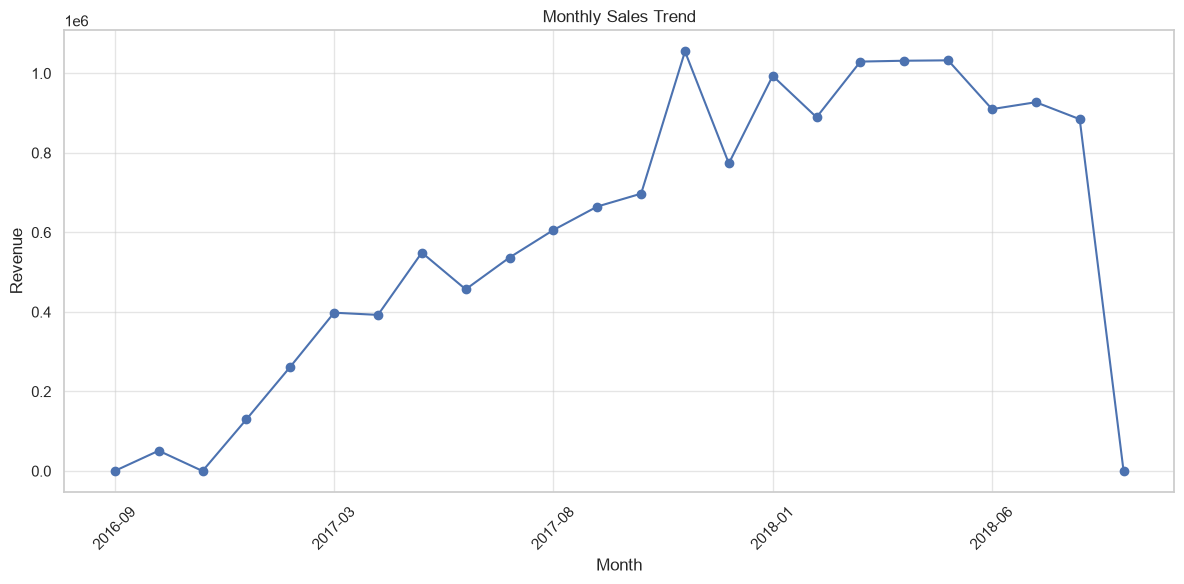

In [40]:
monthly_sales = (
    merged.groupby(
        merged["order_purchase_timestamp"].dt.to_period("M")
    )["price"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,6))
monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../visuals/monthly_sales.png")
plt.show()

## 💳 Payment Method Distribution

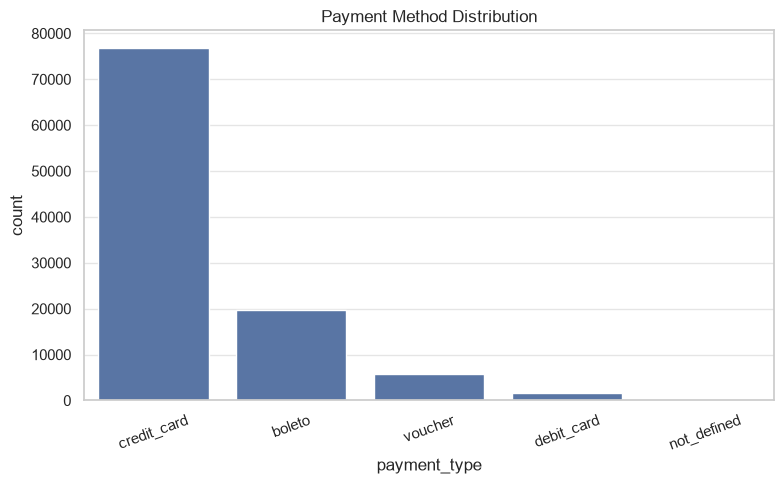

In [41]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=payments,
    x="payment_type"
)

plt.title("Payment Method Distribution")
plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig("../visuals/payment_methods.png")
plt.show()

## ⭐ Review Score Distribution

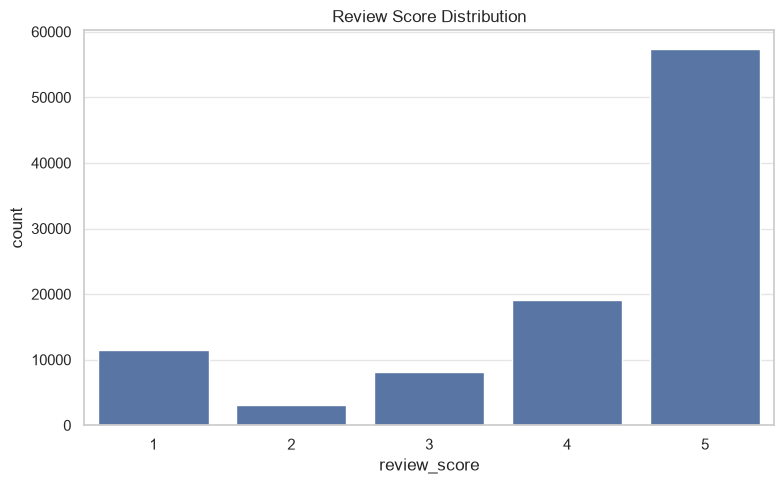

In [42]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=reviews,
    x="review_score"
)

plt.title("Review Score Distribution")

plt.tight_layout()
plt.savefig("../visuals/review_distribution.png")
plt.show()

## 🏆 Top 10 Product Categories

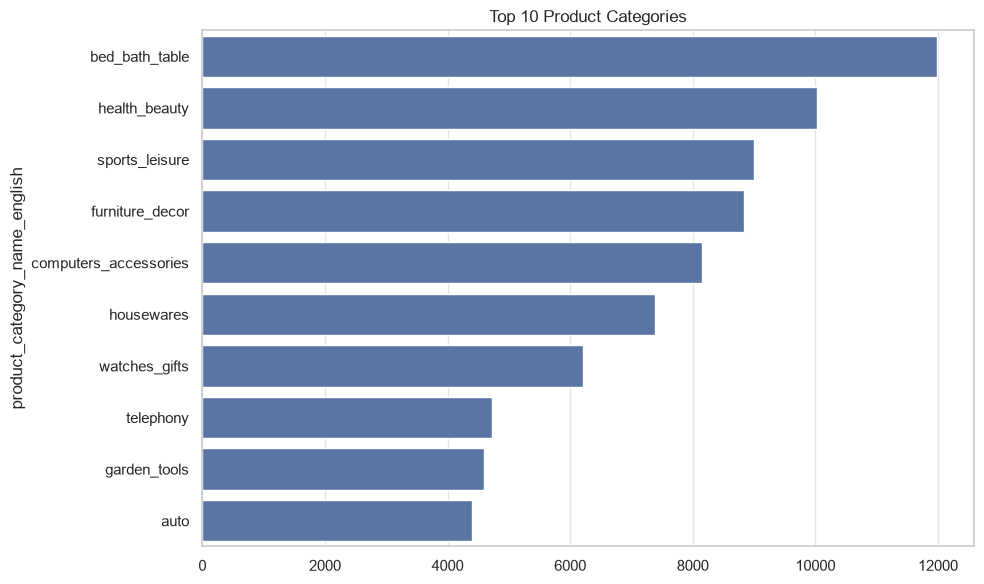

In [43]:
top_categories = (
    merged["product_category_name_english"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title("Top 10 Product Categories")

plt.tight_layout()
plt.savefig("../visuals/top_categories.png")
plt.show()

## 🌍 Orders by State

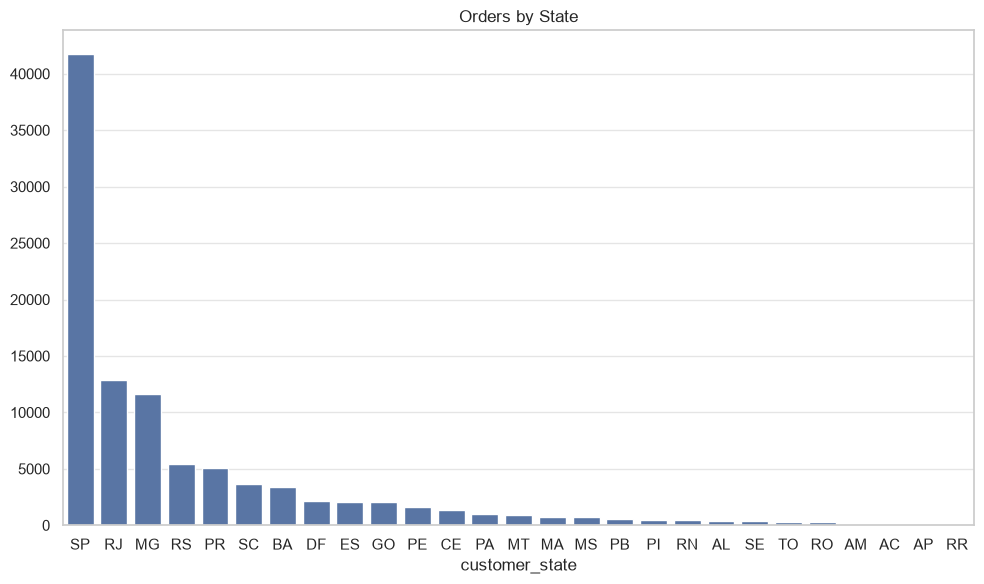

In [44]:
top_states = (
    customers["customer_state"]
    .value_counts()
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_states.index,
    y=top_states.values
)

plt.title("Orders by State")

plt.tight_layout()
plt.savefig("../visuals/orders_by_state.png")
plt.show()

# 📊 Business Insights

## 1. Monthly Sales Trend
- Revenue changes across different months, indicating seasonal demand.
- Sales peaks can help businesses plan inventory and marketing campaigns.

## 2. Payment Methods
- Credit cards are the most frequently used payment method.
- Businesses should continue optimizing card payment experiences.

## 3. Customer Reviews
- Most customers gave ratings of 4 or 5.
- Overall customer satisfaction is high.

## 4. Product Categories
- A few product categories contribute to most of the sales.
- These categories should receive greater marketing attention.

## 5. Orders by State
- Some states generate significantly more orders than others.
- Businesses can focus logistics and advertising in these high-demand regions.

## 6. Delivery Performance
- The average delivery time is approximately 12 days.
- Improving delivery speed may further increase customer satisfaction.